\newpage

## 1.

This is a binary classification problem, with the goal of predicting the presence of heart disease based on the patient's medical records (converting the original response variable num to binary: 0 represents no heart disease, 1 represents heart disease)

## 2.

The qualitative and quantitative variables in the data have been clearly distinguished and do not require conversion. Subsequently, according to the analysis needs, the target variable can be changed from a multi class variable to a binary class variable

## 3.

In [2]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
import warnings
warnings.filterwarnings("ignore", category=UserWarning, 
                        module="sklearn.cluster._kmeans")
warnings.filterwarnings("ignore", category=UserWarning,
                        module="joblib.externals.loky.backend.context")

In [3]:
import pandas as pd
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [4]:
print(df.dtypes)
print(df.shape[0])
print(df.shape[1])
print(df.describe())
print(df.head())

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object
303
14
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.0000

The dataset contains 303 observations and 14 variables.There are some missing values in variables ca and tahl.The standard deviation of the chol variable is relatively large, and there may be extreme or outlier values far from the mean

## 4.

In [5]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
print(df['num'].value_counts())

num
0    164
1    139
Name: count, dtype: int64


## 5.

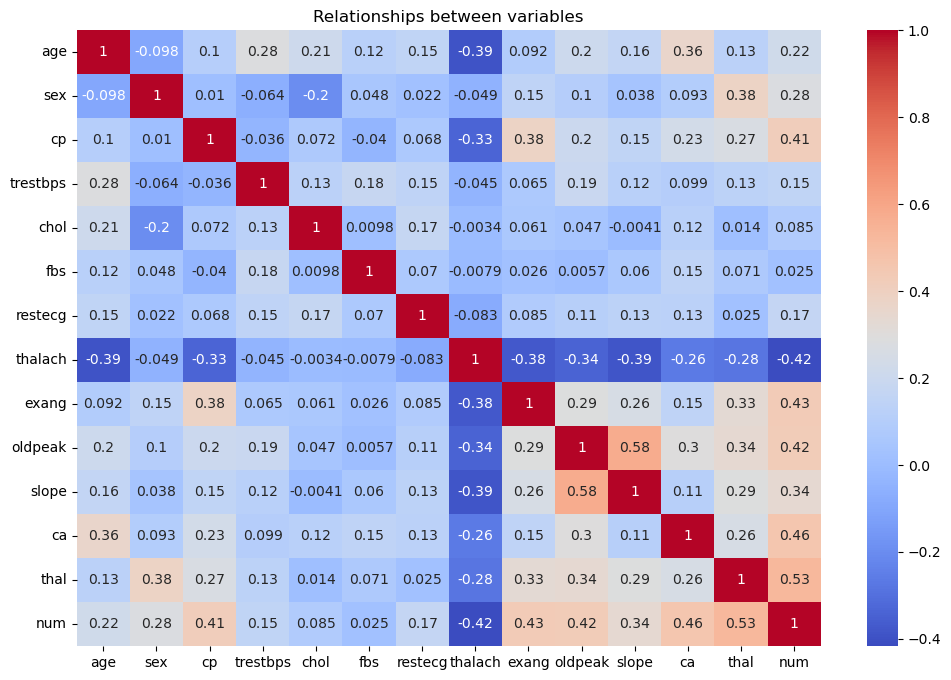

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
corrmatrix = df.corr()
sns.heatmap(corrmatrix, annot=True, cmap='coolwarm')
plt.title("Relationships between variables")
plt.show()

The relationship between thalach variable and other variables is negatively correlated.The variable that has the greatest positive correlation with heart disease is Thal, and the variable that has the greatest negative correlation is Thalach.

## 6.

In [7]:
data = df.dropna()
print(data.shape[0])

297


There 297 osbervations after dropping the missing values.

## 7.

For k = 2, Silhouette Score = 0.2330
For k = 3, Silhouette Score = 0.2153
For k = 4, Silhouette Score = 0.1861
For k = 5, Silhouette Score = 0.1867
For k = 6, Silhouette Score = 0.1723
For k = 7, Silhouette Score = 0.1798
For k = 8, Silhouette Score = 0.1607
For k = 9, Silhouette Score = 0.1674


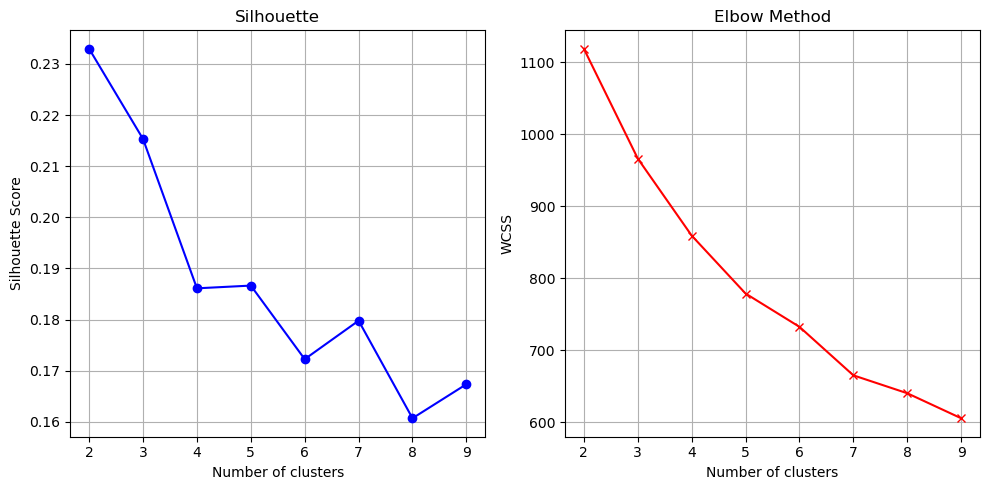

2


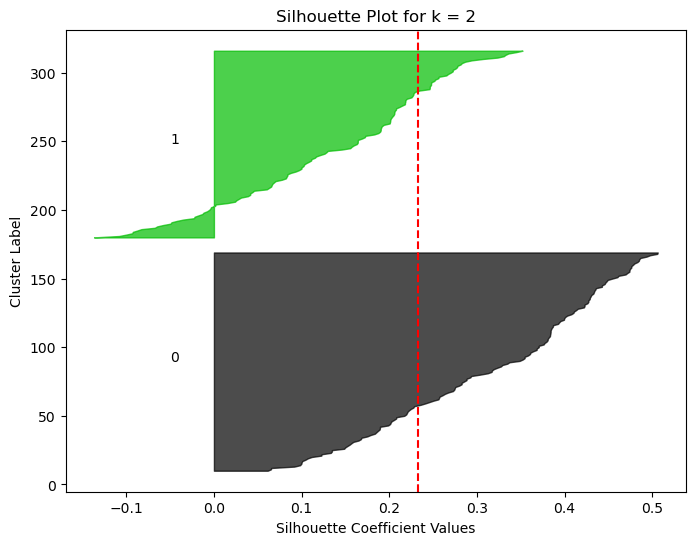

               age    trestbps        chol     thalach   oldpeak
cluster                                                         
0        49.087500  125.712500  236.156250  162.750000  0.533750
1        60.912409  138.678832  260.423358  134.240876  1.664964


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
data = data.copy()  

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
X = data[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K = range(2, 10)
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    print(f"For k = {k}, Silhouette Score = {silhouette_avg:.4f}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(K, silhouette_scores, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette')
plt.grid(True)

distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_scaled)
    distortions.append(kmeans.inertia_)

plt.subplot(1, 2, 2)
plt.plot(K, distortions, 'rx-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k = np.argmax(silhouette_scores) + 2  
print(optimal_k)

kmeans = KMeans(n_clusters=optimal_k, random_state=1)
cluster_labels = kmeans.fit_predict(X_scaled)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

plt.figure(figsize=(8, 6))
y_lower = 10
for i in range(optimal_k):
    
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / optimal_k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.title(f"Silhouette Plot for k = {optimal_k}")
plt.show()

final_kmeans = KMeans(n_clusters=optimal_k, random_state=1)
final_clusters = final_kmeans.fit_predict(X_scaled)
data.loc[:, 'cluster'] = final_clusters

print(data.groupby('cluster')[numeric_cols].mean())

The peak appears at k=2, indicating the best separation between the two subgroups.The characteristics of subgroup 1 are younger age, lower blood pressure, higher maximum heart rate, and mild ST depression. The characteristics of subgroup 2 are older age, higher blood pressure, lower maximum heart rate, and significant ST depression.Subgroup 1 may represent the "low-risk" group (young, with good cardiovascular indicators), while Subgroup 2 may represent the "high-risk" group (older, with obvious signs of myocardial ischemia).

## 8.

In [9]:
from sklearn.model_selection import train_test_split
X = data.drop(['num'], axis=1)
y = data['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

X_train_encode = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encode = pd.get_dummies(X_test, columns=categorical_cols)
missing_cols = set(X_train_encode.columns) - set(X_test_encode.columns)
for col in missing_cols:
    X_test_encode[col] = 0
X_test_encode = X_test_encode[X_train_encode.columns]

scaler = StandardScaler()
X_train_encode[numeric_cols] = scaler.fit_transform(X_train_encode[numeric_cols])
X_test_encode[numeric_cols] = scaler.transform(X_test_encode[numeric_cols])

## 9.

1. Logistic regression model - Strong interpretability, meets homework requirements.
2. Random Forest model- As a comparative ensemble method, it usually has good predictive performance.

## 10.

1. Accuracy: The proportion of correct predictions, (TP + TN) / (TP + FP + TN + FN).
2. ROC AUC: A measure of a model's discriminative ability, calculating the area under the ROC curve.

## 11.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
logreg = LogisticRegression(max_iter=1000, random_state=1)
logreg.fit(X_train_encode, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train_encode, y_train)

RandomForestClassifier(random_state=1)

## 12.

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_encode, y_train)
X_test_selected = selector.transform(X_test_encode)

logreg_selected = LogisticRegression(max_iter=1000, random_state=1)
logreg_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=1000, random_state=1)

## 13.

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred_logreg = logreg.predict(X_test_encode)
logreg_acc = accuracy_score(y_test, y_pred_logreg)
logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test_encode)[:, 1])

y_pred_rf = rf.predict(X_test_encode)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_encode)[:, 1])

y_pred_logreg_sel = logreg_selected.predict(X_test_selected)
logreg_sel_acc = accuracy_score(y_test, y_pred_logreg_sel)
logreg_sel_auc = roc_auc_score(y_test, logreg_selected.predict_proba(X_test_selected)[:, 1])

print(logreg_acc)
print(logreg_auc)
print(rf_acc)
print(rf_auc)
print(logreg_sel_acc)
print(logreg_sel_auc)

0.7888888888888889
0.8959276018099548
0.8444444444444444
0.905982905982906
0.8555555555555555
0.9165409753645047


The accuracy of logistic regression (all features) is 0.7889, with an AUC of 0.8959. The accuracy of random forest (all features) is 0.8444, with an AUC of 0.9060. The accuracy of logistic regression (feature selection) is 0.8556, with an AUC of 0.9165.Random forest performs the best on the test set, with the highest accuracy and AUC compared to logistic regression. The accuracy and AUC of the logistic regression after feature selection have been improved, using the inverse hyper random forest model. 
Feature selection reduces model complexity, improves interpretability and computational efficiency of the model